# Employee Financial Health Prediction Model

This notebook focuses on developing machine learning models capable of predicting employee financial health based on demographic characteristics, payroll information, financial behaviour, and engineered financial features.

The primary objective is to identify the model that provides the best predictive performance while maintaining interpretability. Multiple classification algorithms are evaluated and compared using standard performance metrics. The selected model is subsequently interpreted using explainable AI techniques before being saved for deployment within the financial recommendation system.

The workflow implemented in this notebook consists of the following stages:

- Data Loading
- Data Preprocessing
- Train-Test Split
- Feature Scaling
- Baseline Model Comparison
- Hyperparameter Optimization
- Final Model Evaluation
- Model Explainability
- Model Persistence

In [70]:
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Load Processed Dataset

The processed dataset generated during the feature engineering stage is loaded for model development. This dataset contains the validated financial variables together with the engineered behavioural features that will be used for predictive modelling.

In [71]:
df = pd.read_csv("../data/processed/employee_financial_procssed.csv")

df.head()

,EmployeeID,EmployeeName,Age,Years_of_Experience,Department,Monthly_Salary,Income_Tax,PF_Contribution,Insurance_Deduction,Other_Deductions,...,Class,Expense_Ratio,Savings_Ratio,Investment_Ratio,EMI_Ratio,Disposable_Income,Financial_Cushion,Debt_Burden_Index,Investment_to_Savings_Ratio,Financial_Health
0,EMP00001,Gaurav Akash Chauhan,29,2,Marketing,55811,1124,3349,744,1183,...,High,0.227156,0.338811,0.100241,0.000000,38187,1.49,0.000,0.296,2
1,EMP00002,Vivek Aman Nagpal,49,20,Cyber Security,152405,13814,9144,3436,1697,...,Low,0.608065,0.001794,0.004448,0.326488,48723,0.00,0.266,2.469,0
2,EMP00003,Amit Bhardwaj,40,9,Operations,67086,1709,4025,1366,1399,...,Low,0.450253,0.050865,0.017171,0.221619,32208,0.11,0.194,0.337,0
3,EMP00004,Avantika Arora,25,1,Operations,51199,893,3072,1148,1563,...,Medium,0.503201,0.288076,0.035892,0.106282,22119,0.57,0.092,0.125,1
4,EMP00005,Reema Patel,30,6,Sales,51015,884,3061,1105,1294,...,Medium,0.523472,0.220456,0.058091,0.000000,21287,0.42,0.000,0.263,1


In [72]:
print("Shape :", df.shape)

df.info()

Shape : (10000, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   EmployeeID                   10000 non-null  object 
 1   EmployeeName                 10000 non-null  object 
 2   Age                          10000 non-null  int64  
 3   Years_of_Experience          10000 non-null  int64  
 4   Department                   10000 non-null  object 
 5   Monthly_Salary               10000 non-null  int64  
 6   Income_Tax                   10000 non-null  int64  
 7   PF_Contribution              10000 non-null  int64  
 8   Insurance_Deduction          10000 non-null  int64  
 9   Other_Deductions             10000 non-null  int64  
 10  Net_Salary                   10000 non-null  int64  
 11  Rent_Expense                 10000 non-null  int64  
 12  Grocery_Expense              10000 non-null  int64  
 1

In [73]:
drop_columns = [

    "EmployeeID",

    "EmployeeName",

    "Financial_Health"

]

df = df.drop(columns=drop_columns)

print(df.shape)

(10000, 26)


In [74]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

df["Class"] = target_encoder.fit_transform(df["Class"])

print(target_encoder.classes_)

['High' 'Low' 'Medium']


In [75]:
y = df["Class"]

To evaluate the effectiveness of feature engineering, three progressively richer feature sets are constructed.

The first feature set contains only the original demographic, payroll, and financial variables. The second feature set augments these variables with behavioural financial ratios, while the third incorporates the newly engineered domain-specific financial features.

Comparing model performance across these feature sets provides quantitative evidence regarding the contribution of behavioural analysis and feature engineering towards employee financial health prediction.

In [76]:
raw_features = [

    "Age",
    "Years_of_Experience",
    "Department",

    "Monthly_Salary",
    "Income_Tax",
    "PF_Contribution",
    "Insurance_Deduction",
    "Other_Deductions",
    "Net_Salary",

    "Rent_Expense",
    "Grocery_Expense",
    "EMI_or_Loan_Payment",
    "Entertainment_Expense",
    "Other_Expenses",
    "Total_Expenditure",

    "Savings_Amount",
    "Investments"

]

In [77]:
behaviour_features = raw_features + [

    "Expense_Ratio",

    "Savings_Ratio",

    "Investment_Ratio",

    "EMI_Ratio"

]

In [78]:
engineered_features = behaviour_features + [

    "Disposable_Income",

    "Financial_Cushion",

    "Debt_Burden_Index",

    "Investment_to_Savings_Ratio"

]

In [79]:
print("Raw Features :", len(raw_features))

print("Behaviour Features :", len(behaviour_features))

print("Engineered Features :", len(engineered_features))

Raw Features : 17
Behaviour Features : 21
Engineered Features : 25


To ensure consistency and reduce code duplication, a reusable training framework is developed for model evaluation.

The framework performs the complete machine learning workflow, including:

- Feature selection
- Train-test split
- Feature encoding
- Feature scaling (where required)
- Model training
- Prediction
- Performance evaluation

This modular approach enables multiple feature sets and machine learning algorithms to be evaluated using identical preprocessing steps, ensuring a fair comparison of predictive performance.

In [80]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    classification_report,

    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier

In [81]:
def get_feature_types(df, feature_list):

    categorical_features = []

    numerical_features = []

    for col in feature_list:

        if df[col].dtype == "object":

            categorical_features.append(col)

        else:

            numerical_features.append(col)

    return numerical_features, categorical_features

In [82]:
def build_preprocessor(

    numerical_features,

    categorical_features,

    scale_numeric=True

):

    transformers = []

    if numerical_features:

        if scale_numeric:

            transformers.append(

                (

                    "num",

                    StandardScaler(),

                    numerical_features

                )

            )

        else:

            transformers.append(

                (

                    "num",

                    "passthrough",

                    numerical_features

                )

            )

    if categorical_features:

        transformers.append(

            (

                "cat",

                OneHotEncoder(

                    handle_unknown="ignore"

                ),

                categorical_features

            )

        )

    preprocessor = ColumnTransformer(

        transformers=transformers

    )

    return preprocessor

In [83]:
def train_model(

    df,

    feature_list,

    target,

    model,

    scale_numeric=True,

    test_size=0.20,

    random_state=42

):

    X = df[feature_list]

    y = df[target]

    num_cols, cat_cols = get_feature_types(

        df,

        feature_list

    )

    X_train, X_test, y_train, y_test = train_test_split(

        X,

        y,

        test_size=test_size,

        random_state=random_state,

        stratify=y

    )

    preprocessor = build_preprocessor(

        num_cols,

        cat_cols,

        scale_numeric

    )

    pipeline = Pipeline(

        steps=[

            ("preprocessor", preprocessor),

            ("model", model)

        ]

    )

    pipeline.fit(

        X_train,

        y_train

    )

    y_pred = pipeline.predict(

        X_test

    )

    metrics = {

        "Accuracy": accuracy_score(

            y_test,

            y_pred

        ),

        "Precision": precision_score(

            y_test,

            y_pred,

            average="weighted"

        ),

        "Recall": recall_score(

            y_test,

            y_pred,

            average="weighted"

        ),

        "F1": f1_score(

            y_test,

            y_pred,

            average="weighted"

        )

    }

    return (

        pipeline,

        metrics,

        y_test,

        y_pred

    )

In [84]:
def train_model_v2(
    df,
    feature_list,
    target,
    model,
    scale_numeric=True,
    test_size=0.20,
    random_state=42
):

    X = df[feature_list]
    y = df[target]

    num_cols, cat_cols = get_feature_types(df, feature_list)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    preprocessor = build_preprocessor(
        num_cols,
        cat_cols,
        scale_numeric
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1": f1_score(y_test, y_pred, average="weighted")
    }

    return (
        pipeline,
        metrics,
        X_train,
        X_test,
        y_train,
        y_test,
        y_pred
    )

Before comparing multiple machine learning algorithms, it is important to evaluate whether the behavioural financial indicators and newly engineered features improve predictive performance.

To isolate the effect of feature engineering, a Random Forest classifier is trained independently on three progressively richer feature sets.

Using the same learning algorithm across all experiments ensures that any performance improvement can be attributed to the additional engineered features rather than differences between machine learning models.

In [85]:
rf_model = RandomForestClassifier(

    n_estimators=200,

    random_state=42

)

In [86]:
raw_pipeline, raw_metrics, _, _ = train_model(

    df=df,

    feature_list=raw_features,

    target="Class",

    model=rf_model,

    scale_numeric=False

)

raw_metrics

{'Accuracy': 0.8445,
 'Precision': 0.843689121345132,
 'Recall': 0.8445,
 'F1': 0.8434776402339312}

In [87]:
behaviour_pipeline, behaviour_metrics, _, _ = train_model(

    df=df,

    feature_list=behaviour_features,

    target="Class",

    model=rf_model,

    scale_numeric=False

)

behaviour_metrics

{'Accuracy': 0.8445,
 'Precision': 0.8435588592966581,
 'Recall': 0.8445,
 'F1': 0.8439120070069005}

In [88]:
engineered_pipeline, engineered_metrics, _, _ = train_model(

    df=df,

    feature_list=engineered_features,

    target="Class",

    model=rf_model,

    scale_numeric=False

)

engineered_metrics

{'Accuracy': 0.846,
 'Precision': 0.8453048013793303,
 'Recall': 0.846,
 'F1': 0.8455990438671666}

In [89]:
comparison = pd.DataFrame({

    "Feature Set":[

        "Raw",

        "Behaviour",

        "Engineered"

    ],

    "Accuracy":[

        raw_metrics["Accuracy"],

        behaviour_metrics["Accuracy"],

        engineered_metrics["Accuracy"]

    ],

    "Precision":[

        raw_metrics["Precision"],

        behaviour_metrics["Precision"],

        engineered_metrics["Precision"]

    ],

    "Recall":[

        raw_metrics["Recall"],

        behaviour_metrics["Recall"],

        engineered_metrics["Recall"]

    ],

    "F1 Score":[

        raw_metrics["F1"],

        behaviour_metrics["F1"],

        engineered_metrics["F1"]

    ]

})

comparison

,Feature Set,Accuracy,Precision,Recall,F1 Score
0,Raw,0.8445,0.843689,0.8445,0.843478
1,Behaviour,0.8445,0.843559,0.8445,0.843912
2,Engineered,0.8460,0.845305,0.8460,0.845599


In [90]:
clean_engineered_features = [

    "Age",
    "Years_of_Experience",
    "Department",

    "Monthly_Salary",
    "Income_Tax",
    "PF_Contribution",
    "Insurance_Deduction",
    "Other_Deductions",
    "Net_Salary",

    "Rent_Expense",
    "Grocery_Expense",
    "EMI_or_Loan_Payment",
    "Entertainment_Expense",
    "Other_Expenses",
    "Total_Expenditure",

    "Savings_Amount",
    "Investments",

    "Disposable_Income",

    "Debt_Burden_Index",

    "Investment_to_Savings_Ratio"
]

In [91]:
rf_clean, clean_metrics, _, _ = train_model(

    df=df,

    feature_list=clean_engineered_features,

    target="Class",

    model=RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    scale_numeric=False
)

clean_metrics

{'Accuracy': 0.8425,
 'Precision': 0.8412879538848599,
 'Recall': 0.8425,
 'F1': 0.841314240631787}

In [92]:
comparison = pd.DataFrame({

    "Feature Set":[
        "Raw",
        "Behaviour",
        "Engineered",
        "Clean Engineered"
    ],

    "Accuracy":[
        raw_metrics["Accuracy"],
        behaviour_metrics["Accuracy"],
        engineered_metrics["Accuracy"],
        clean_metrics["Accuracy"]
    ],

    "Precision":[
        raw_metrics["Precision"],
        behaviour_metrics["Precision"],
        engineered_metrics["Precision"],
        clean_metrics["Precision"]
    ],

    "Recall":[
        raw_metrics["Recall"],
        behaviour_metrics["Recall"],
        engineered_metrics["Recall"],
        clean_metrics["Recall"]
    ],

    "F1 Score":[
        raw_metrics["F1"],
        behaviour_metrics["F1"],
        engineered_metrics["F1"],
        clean_metrics["F1"]
    ]
})

comparison

,Feature Set,Accuracy,Precision,Recall,F1 Score
0,Raw,0.8445,0.843689,0.8445,0.843478
1,Behaviour,0.8445,0.843559,0.8445,0.843912
2,Engineered,0.8460,0.845305,0.8460,0.845599
3,Clean Engineered,0.8425,0.841288,0.8425,0.841314


In [93]:
demographic_features = [

    "Age",

    "Years_of_Experience",

    "Department"

]

rf_demo, demo_metrics, _, _ = train_model(

    df=df,

    feature_list=demographic_features,

    target="Class",

    model=RandomForestClassifier(
        random_state=42,
        n_estimators=200
    ),

    scale_numeric=False
)

demo_metrics

{'Accuracy': 0.506,
 'Precision': 0.46521856332006484,
 'Recall': 0.506,
 'F1': 0.48011514911772735}

After identifying the final feature set, multiple machine learning algorithms are evaluated to determine the most suitable model for predicting employee financial health.

Each algorithm is trained using the same training and testing data, identical preprocessing pipeline, and identical evaluation metrics to ensure a fair comparison.

The evaluated algorithms include:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

Model performance is assessed using Accuracy, Precision, Recall, and F1-Score.

In [94]:
final_features = clean_engineered_features

In [95]:
lr_pipeline, lr_metrics, X_train, X_test, y_train, y_test, lr_pred = train_model_v2(

    df=df,

    feature_list=final_features,

    target="Class",

    model=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    scale_numeric=True

)

lr_metrics

{'Accuracy': 0.83,
 'Precision': 0.8275057807308384,
 'Recall': 0.83,
 'F1': 0.8275581503179262}

In [96]:

dt_pipeline, dt_metrics, _, _, _, _, dt_pred = train_model_v2(

    df=df,

    feature_list=final_features,

    target="Class",

    model=DecisionTreeClassifier(
        random_state=42
    ),

    scale_numeric=False

)

dt_metrics

{'Accuracy': 0.793,
 'Precision': 0.7932174202302271,
 'Recall': 0.793,
 'F1': 0.793101156381322}

In [97]:

rf_pipeline, rf_metrics, _, _, _, _, rf_pred = train_model_v2(

    df=df,

    feature_list=final_features,

    target="Class",

    model=RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    scale_numeric=False

)

rf_metrics

{'Accuracy': 0.8425,
 'Precision': 0.8412879538848599,
 'Recall': 0.8425,
 'F1': 0.841314240631787}

In [98]:

xgb_pipeline, xgb_metrics, _, _, _, _, xgb_pred = train_model_v2(

    df=df,

    feature_list=final_features,

    target="Class",

    model=XGBClassifier(
        n_estimators=200,
        random_state=42,
        eval_metric="mlogloss"
    ),

    scale_numeric=False

)

xgb_metrics

{'Accuracy': 0.8355,
 'Precision': 0.8346829814970634,
 'Recall': 0.8355,
 'F1': 0.8349565902209587}

In [99]:
model_results = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Decision Tree",

        "Random Forest",

        "XGBoost"

    ],

    "Accuracy":[

        lr_metrics["Accuracy"],

        dt_metrics["Accuracy"],

        rf_metrics["Accuracy"],

        xgb_metrics["Accuracy"]

    ],

    "Precision":[

        lr_metrics["Precision"],

        dt_metrics["Precision"],

        rf_metrics["Precision"],

        xgb_metrics["Precision"]

    ],

    "Recall":[

        lr_metrics["Recall"],

        dt_metrics["Recall"],

        rf_metrics["Recall"],

        xgb_metrics["Recall"]

    ],

    "F1 Score":[

        lr_metrics["F1"],

        dt_metrics["F1"],

        rf_metrics["F1"],

        xgb_metrics["F1"]

    ]

})

model_results.sort_values(
    "F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.8425,0.841288,0.8425,0.841314
3,XGBoost,0.8355,0.834683,0.8355,0.834957
0,Logistic Regression,0.8300,0.827506,0.8300,0.827558
1,Decision Tree,0.7930,0.793217,0.7930,0.793101


After evaluating multiple machine learning algorithms, the Random Forest classifier achieved the highest predictive performance on the employee financial health dataset.

To further improve model performance, hyperparameter tuning is performed using RandomizedSearchCV. Rather than relying on default parameters, the search explores multiple combinations of hyperparameters to identify a configuration that maximizes the weighted F1-score through cross-validation.

This process aims to improve the model's generalization capability while reducing the risk of overfitting.

In [100]:
from sklearn.model_selection import RandomizedSearchCV

In [101]:
rf_param_grid = {

    "model__n_estimators": [100, 200, 300, 500],

    "model__max_depth": [None, 10, 20, 30, 40],

    "model__min_samples_split": [2, 5, 10],

    "model__min_samples_leaf": [1, 2, 4],

    "model__max_features": ["sqrt", "log2"]

}

In [102]:
rf_pipeline, _, _, _, _, _, _ = train_model_v2(

    df=df,

    feature_list=final_features,

    target="Class",

    model=RandomForestClassifier(
        random_state=42
    ),

    scale_numeric=False
)

In [103]:
random_search = RandomizedSearchCV(

    estimator=rf_pipeline,

    param_distributions=rf_param_grid,

    n_iter=20,

    cv=5,

    scoring="f1_weighted",

    random_state=42,

    n_jobs=-1

)

random_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [104]:
print("Best Parameters:\n")

print(random_search.best_params_)

print("\nBest CV Score:")

print(random_search.best_score_)

Best Parameters:

{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': None}

Best CV Score:
0.8420154567228206


In [105]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

best_rf = random_search.best_estimator_

rf_pred = best_rf.predict(X_test)

rf_results = {

    "Accuracy": accuracy_score(y_test, rf_pred),

    "Precision": precision_score(y_test, rf_pred, average="weighted"),

    "Recall": recall_score(y_test, rf_pred, average="weighted"),

    "F1 Score": f1_score(y_test, rf_pred, average="weighted")

}

pd.DataFrame([rf_results])

,Accuracy,Precision,Recall,F1 Score
0,0.841,0.839903,0.841,0.840097


In [106]:
xgb_param_grid = {

    "model__n_estimators": [100, 200, 300, 500],

    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],

    "model__max_depth": [3, 4, 5, 6, 8],

    "model__subsample": [0.8, 0.9, 1.0],

    "model__colsample_bytree": [0.8, 0.9, 1.0]

}

In [107]:
random_search_xgb = RandomizedSearchCV(

    estimator=xgb_pipeline,

    param_distributions=xgb_param_grid,

    n_iter=20,

    cv=5,

    scoring="f1_weighted",

    random_state=42,

    n_jobs=-1

)

random_search_xgb.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': [0.8, 0.9, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 4, ...], 'model__n_estimators': [100, 200, ...], ...}"
,n_iter,20
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [108]:
print(random_search_xgb.best_params_)
print(random_search_xgb.best_score_)

{'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 4, 'model__learning_rate': 0.2, 'model__colsample_bytree': 0.8}
0.8437402317712461


In [109]:
best_xgb = random_search_xgb.best_estimator_

xgb_pred = best_xgb.predict(X_test)

xgb_results = {

    "Accuracy": accuracy_score(y_test, xgb_pred),

    "Precision": precision_score(y_test, xgb_pred, average="weighted"),

    "Recall": recall_score(y_test, xgb_pred, average="weighted"),

    "F1 Score": f1_score(y_test, xgb_pred, average="weighted")

}

pd.DataFrame([xgb_results])

,Accuracy,Precision,Recall,F1 Score
0,0.839,0.83835,0.839,0.838638


# Final Model Evaluation

The selected XGBoost model is evaluated using multiple performance metrics to understand its predictive capability and generalization performance.

Rather than relying solely on overall accuracy, the evaluation includes confusion matrix analysis, per-class classification metrics, feature importance, and cross-validation performance.

These analyses provide a comprehensive understanding of the strengths and limitations of the final model before deployment.

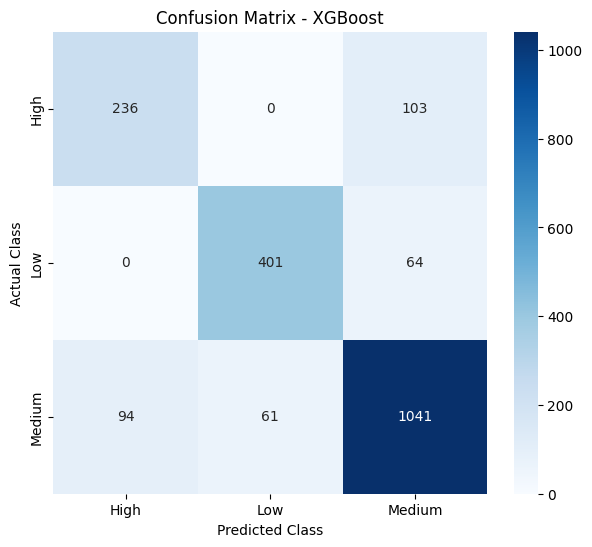

In [110]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(7,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=target_encoder.classes_,

    yticklabels=target_encoder.classes_

)

plt.xlabel("Predicted Class")

plt.ylabel("Actual Class")

plt.title("Confusion Matrix - XGBoost")

plt.show()

In [111]:
from sklearn.metrics import classification_report

report = classification_report(

    y_test,

    xgb_pred,

    target_names=target_encoder.classes_,

    output_dict=True

)

report_df = pd.DataFrame(report).transpose()

report_df.round(3)

,precision,recall,f1-score,support
High,0.715,0.696,0.706,339.000
Low,0.868,0.862,0.865,465.000
Medium,0.862,0.870,0.866,1196.000
accuracy,0.839,0.839,0.839,0.839
macro avg,0.815,0.810,0.812,2000.000
weighted avg,0.838,0.839,0.839,2000.000


In [112]:
feature_names = (
    best_xgb.named_steps["preprocessor"]
            .get_feature_names_out()
)

importances = (
    best_xgb.named_steps["model"]
            .feature_importances_
)

importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importances

})

importance_df = importance_df.sort_values(

    "Importance",

    ascending=False

)

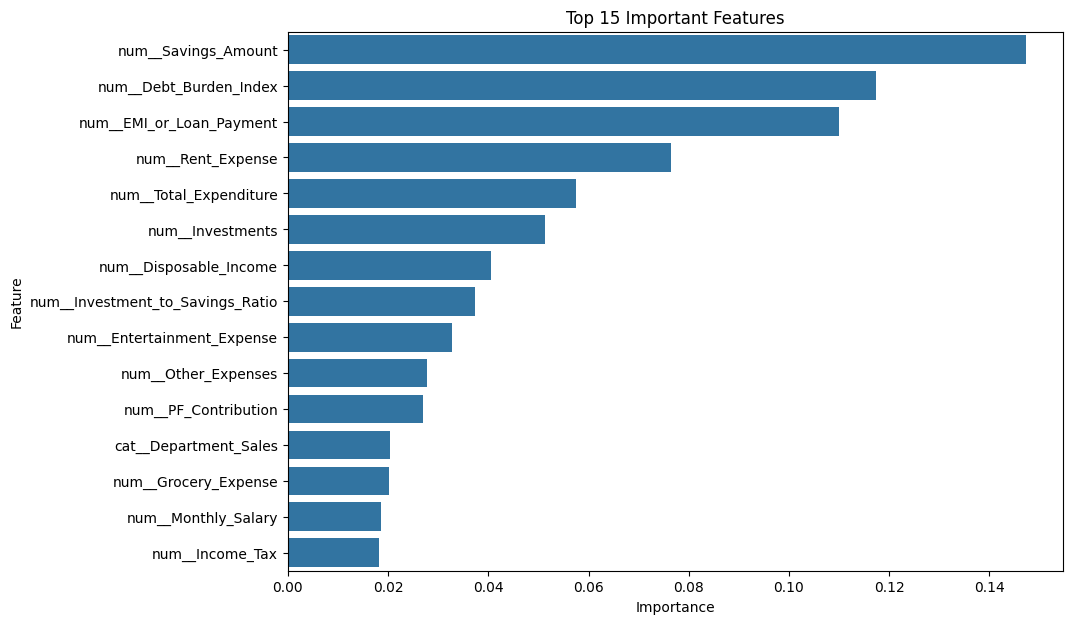

In [113]:
plt.figure(figsize=(10,7))

top_features = importance_df.head(15)

sns.barplot(

    data=top_features,

    x="Importance",

    y="Feature"

)

plt.title("Top 15 Important Features")

plt.show()

In [114]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(

    best_xgb,

    df[final_features],

    df["Class"],

    cv=5,

    scoring="f1_weighted",

    n_jobs=-1

)

print("Cross Validation Scores")

print(cv_scores)

print()

print("Average CV Score")

print(cv_scores.mean())

Cross Validation Scores
[0.85027212 0.83916999 0.85183395 0.84363293 0.84534655]

Average CV Score
0.8460511081055054


In [115]:
summary = pd.DataFrame({

    "Metric":[

        "Test Accuracy",

        "Weighted Precision",

        "Weighted Recall",

        "Weighted F1",

        "Average CV Score"

    ],

    "Value":[

        xgb_results["Accuracy"],

        xgb_results["Precision"],

        xgb_results["Recall"],

        xgb_results["F1 Score"],

        cv_scores.mean()

    ]

})

summary

,Metric,Value
0,Test Accuracy,0.839000
1,Weighted Precision,0.838350
2,Weighted Recall,0.839000
3,Weighted F1,0.838638
4,Average CV Score,0.846051


### Final Evaluation Summary

The tuned XGBoost model demonstrated strong and consistent predictive performance across both the independent test set and five-fold cross-validation.

The confusion matrix indicates that the model correctly classifies the majority of employee financial health categories, while the classification report shows balanced precision, recall, and F1-scores across all classes.

Feature importance analysis reveals that financial indicators such as disposable income, debt burden, savings, and investment-related variables contribute most significantly to the model's predictions.

The close agreement between cross-validation performance and test performance suggests that the model generalizes well and is suitable for deployment within the financial recommendation system.

In [117]:
import os

os.makedirs("models", exist_ok=True)

In [118]:
import joblib

joblib.dump(
    best_xgb,
    "models/final_xgboost_pipeline.pkl"
)

['models/final_xgboost_pipeline.pkl']

In [119]:
joblib.dump(
    target_encoder,
    "models/target_encoder.pkl"
)

['models/target_encoder.pkl']

In [120]:
joblib.dump(
    final_features,
    "models/final_features.pkl"
)

['models/final_features.pkl']

In [121]:
loaded_pipeline = joblib.load("models/final_xgboost_pipeline.pkl")
loaded_encoder = joblib.load("models/target_encoder.pkl")
loaded_features = joblib.load("models/final_features.pkl")

print("Pipeline Loaded Successfully")
print("Target Encoder Loaded Successfully")
print("Feature List Loaded Successfully")

Pipeline Loaded Successfully
Target Encoder Loaded Successfully
Feature List Loaded Successfully
